In [10]:
import zipfile

zip_path = "/content/archive.zip"   # Replace with your ZIP file name

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

First 5 Rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Last 5 Rows:
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  

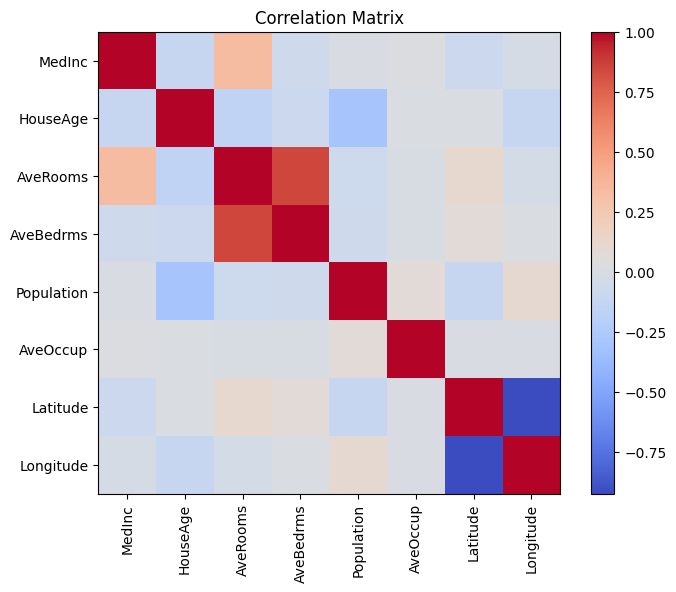


Dataset Analysis Completed Successfully!


In [14]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Display Dataset Overview
# ---------------------------------------------------------
print("First 5 Rows:")
print(df.head())

print("\nLast 5 Rows:")
print(df.tail())

print("\nShape of Dataset:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

# ---------------------------------------------------------
# Categorical & Value Summaries
# ---------------------------------------------------------
if "Branch" in df.columns:
    print("\nUnique Branches:", df["Branch"].unique())
if "City" in df.columns:
    print("\nUnique Cities:", df["City"].unique())
if "Product line" in df.columns:
    print("\nUnique Product Lines:", df["Product line"].unique())

# Handle potential column name differences (e.g., Total vs Sales)
sales_col = "Sales" if "Sales" in df.columns else "Total"

if sales_col in df.columns:
    print(f"\nTotal {sales_col}:", df[sales_col].sum())
    print(f"Maximum {sales_col}:", df[sales_col].max())
    print(f"Minimum {sales_col}:", df[sales_col].min())

if "Rating" in df.columns:
    print("\nAverage Rating:", df["Rating"].mean())

# ---------------------------------------------------------
# Visualizations
# ---------------------------------------------------------
# 1. Branch-wise Sales
if "Branch" in df.columns and sales_col in df.columns:
    branch_sales = df.groupby("Branch")[sales_col].sum()
    print("\nBranch-wise Sales:\n", branch_sales)
    branch_sales.plot(kind="bar", figsize=(6, 4))
    plt.title("Branch-wise Sales")
    plt.xlabel("Branch")
    plt.ylabel(f"Total {sales_col}")
    plt.grid(True)
    plt.show()

# 2. Product Line Sales
if "Product line" in df.columns and sales_col in df.columns:
    product_sales = df.groupby("Product line")[sales_col].sum()
    print("\nProduct Line Sales:\n", product_sales)
    product_sales.plot(kind="bar", figsize=(10, 5))
    plt.title("Product Line Sales")
    plt.xlabel("Product Line")
    plt.ylabel(f"Total {sales_col}")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()

# 3. Payment Method Distribution
if "Payment" in df.columns:
    payment = df["Payment"].value_counts()
    print("\nPayment Methods:\n", payment)
    payment.plot(kind="pie", autopct="%1.1f%%", figsize=(6, 6))
    plt.title("Payment Method Distribution")
    plt.ylabel("")
    plt.show()

# 4. Customer Type Distribution
if "Customer type" in df.columns:
    customer = df["Customer type"].value_counts()
    print("\nCustomer Type Distribution:\n", customer)
    customer.plot(kind="bar", figsize=(5, 4))
    plt.title("Customer Type")
    plt.xlabel("Customer Type")
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()

# 5. Gender Distribution
if "Gender" in df.columns:
    gender = df["Gender"].value_counts()
    print("\nGender Distribution:\n", gender)
    gender.plot(kind="bar", figsize=(5, 4))
    plt.title("Gender Distribution")
    plt.xlabel("Gender")
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()

# 6. Correlation Matrix
numeric_df = df.select_dtypes(include="number")
if not numeric_df.empty:
    print("\nCorrelation Matrix:\n", numeric_df.corr())
    plt.figure(figsize=(8, 6))
    plt.imshow(numeric_df.corr(), cmap="coolwarm")
    plt.colorbar()
    plt.xticks(range(len(numeric_df.columns)), numeric_df.columns, rotation=90)
    plt.yticks(range(len(numeric_df.columns)), numeric_df.columns)
    plt.title("Correlation Matrix")
    plt.show()

print("\nDataset Analysis Completed Successfully!")

In [12]:
import os
import pandas as pd

# Find the exact path of your extracted CSV file
csv_path = None
for root, dirs, files in os.walk("/content/dataset"):
    for file in files:
        if file.endswith(".csv"):
            csv_path = os.path.join(root, file)
            print("Found CSV file at:", csv_path)
            break

# Load the dataframe directly using the found path
if csv_path:
    df = pd.read_csv(csv_path)
    print("CSV loaded successfully! Shape:", df.shape)
else:
    print(
        "No CSV file found in /content/dataset! Please rerun the extraction cell."
    )

Found CSV file at: /content/dataset/california_housing.csv
CSV loaded successfully! Shape: (20640, 8)
